In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Create the messy dataframe
df = pd.DataFrame({
    "Customer_ID": [1001, "ID1002", None, 1004, -1005, 1006, "one007", 1008, 1009, 1010, "??", 1012, 1013, None, 1015, "cust16", 1017, 1018, 1018, "XYZ"],
    "Name": ["John", "", None, "Mary ", "KOFI", "esi", "123", "Akos@", "Nana", "Kwame", "Abena", "Kojo2", "Linda##", "Michael", "Sarah", "Daniel", " ", "Paul", "Paul", "Unknown123"],
    "Age": [25, "thirty", None, -5, 200, "26yrs", "??", 27, "old", 24, 0, "twenty one", 26, None, 999, 23, "NaN", 28, 28, "unknown"],
    "Gender": ["M", "F", "Male", "female", "m", None, "Unknown", "X", "Boy", "Girl", "", "FEMALE", "Male123", "M", "f", "N/A", "Female", "M", "M", "??"],
    "City": ["Accra", "Kumasi ", None, "123", "ACCRA", "accra", "Ksi", "Tamale", "Tema", "Tema ", "Unknown", "", "Kum@si", "TEMA", "Kumasi", "Acc", "Village", "NULL", "Tema", "??"],
    "Salary": [5000, "7000gh", None, -100, 9999999, "five thousand", 6200, 0, "???", 5300, "NaN", 4700, 999999999, None, "6100", "salary", 6400, 5000, 5000, ""],
    "Loan_Status": ["Approved", "Rejected", None, "APPROVED", "approved", "Yes", "No", "Pending", "Rejected", "", "unknown", "approved", "APPROVE", "Reject", "A", "R", None, "Approved", "Approved", "???"],
    "Year": [2026, "2025", None, 1999, 3000, "two thousand", 2024, -1, 2023, "", "future", 2025, 2024, 2035, None, 2010, "unknown", 2026, 2026, "??"],
    "Credit_Score": [700, None, -50, 1200, "bad", 710, 640, "", 660, "excellent", 715, 0, 680, None, 9999, "low", 710, 700, 700, "???"],
    "Account_Balance": [1200, -500, None, "unknown", 300, 99999999, "", 400, -1000, 750, "NaN", 600, 1000, None, "1250", "balance", 950, 1150, 1150, "???"],
    "Transactions": [12, -5, None, "many", 3, 999, "18x", "", 6, 14, 16, 0, -1, "two", 13, None, 9999, 17, 17, "???"],
    "Device_Type": ["Android", "iOS", None, "ANDROID", "android", "Blackberry", "Symbian", "", "Tablet", "iPhone", "Nokia", "Android123", "IOS", "PC", "Laptop", "unknown", "Android", "Android", None, "???"],
    "Employment": ["Employed", None, "Self", "Jobless", "Retired", "employed", "", "N/A", "Unemployed", "Worker", "Self-employed", "EMPLOYED", "none", "Unknown", "Self", "Retired", "??", "Employed", "Employed", ""],
    "Marital_Status": ["Single", None, "Married", "Complicated", "single", "", "Unknown", "Divorced", "Widowed", "MARRIED", "??", "Single123", "Marry", None, "Single", "Taken", "Complicated", "", "Single", "N/A"],
    "Education": ["Degree", None, "Diploma", "Masters", "PhD", "degree", "", "??", "None", "Diploma123", "Basic", "Unknown", "SHS", "Dropout", "Certificate", None, "Degree", "degree", "Masters", "N/A"],
    "Loan_Amount": [1000, None, -500, "ten thousand", 999999, "", 1800, "loan", 2200, 1600, "NaN", 0, -1400, None, "2300", "???", 1900, 2600, 2600, "unknown"],
    "Interest_Rate": [10, None, -3, 200, "high", "", 13, "low", 0, 9, "11%", 16, -1, 17, None, "rate", 9, 11, 11, "???"],
    "Region": ["Greater Accra", None, "Ashanti", "Northern", "", "unknown", "GA", "123", "Volta", "Ashanti ", "??", "Western", "Eastern", None, "Upper East", "Upper West", "Savannah", "Greater Accra", "", "N/A"],
    "Has_Defaulted": [0, 1, None, "Yes", "No", "", -1, 2, "defaulted", 0, "unknown", 1, 0, None, "True", "False", "??", 0, 0, ""],
    "Online_User": [1, 0, None, "sometimes", "Yes", "", -1, 2, "online", 1, "offline", 0, 1, None, "True", "False", "??", 1, 1, ""],
    "Last_Login_Days": [1, None, -2, 800, "yesterday", "", 7, "never", 0, 2, "many", 9, -10, None, 3650, "today", 8, 1, 1, "???"]
})

print("="*60)
print("ORIGINAL DATASET INFO")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}\n")
print(f"Data types:\n{df.dtypes}\n")
print(f"Info:\n{df.info()}\n")
print(f"Describe:\n{df.describe()}\n")
print(f"Describe all:\n{df.describe(include='all')}\n")

ORIGINAL DATASET INFO
Shape: (20, 21)

First 5 rows:
  Customer_ID   Name     Age  Gender     City   Salary Loan_Status  Year  \
0        1001   John      25       M    Accra     5000    Approved  2026   
1      ID1002         thirty       F  Kumasi    7000gh    Rejected  2025   
2        None    NaN    None    Male      NaN     None         NaN  None   
3        1004  Mary       -5  female      123     -100    APPROVED  1999   
4       -1005   KOFI     200       m    ACCRA  9999999    approved  3000   

  Credit_Score Account_Balance  ... Device_Type Employment Marital_Status  \
0          700            1200  ...     Android   Employed         Single   
1         None            -500  ...         iOS        NaN            NaN   
2          -50            None  ...         NaN       Self        Married   
3         1200         unknown  ...     ANDROID    Jobless    Complicated   
4          bad             300  ...     android    Retired         single   

  Education   Loan_Amount I

In [2]:
# ============================================
# 1. CLEANING FUNCTION FOR TEXT FIELDS
# ============================================

def clean_text(text):
    if pd.isna(text):
        return None
    text = str(text).strip()
    # Remove special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text if text else None

# ============================================
# 2. REMOVE DUPLICATES
# ============================================
initial_shape = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_shape - df.shape[0]} duplicate rows")

# ============================================
# 3. CLEAN CUSTOMER_ID
# ============================================
def clean_customer_id(x):
    if pd.isna(x):
        return np.nan
    x_str = str(x).strip()
    # Extract only digits
    numbers = re.findall(r'\d+', x_str)
    if numbers:
        val = int(numbers[0])
        return val if 0 < val < 10000 else np.nan
    return np.nan

df['Customer_ID'] = df['Customer_ID'].apply(clean_customer_id)
# Fill missing Customer_ID with sequential numbers starting from max+1
max_id = df['Customer_ID'].max()
if pd.isna(max_id):
    max_id = 2000
missing_mask = df['Customer_ID'].isna()
df.loc[missing_mask, 'Customer_ID'] = range(int(max_id)+1, int(max_id)+missing_mask.sum()+1)

# ============================================
# 4. CLEAN NAME
# ============================================
def clean_name(name):
    if pd.isna(name):
        return None
    name = str(name).strip()
    # Remove digits and special chars, keep only letters
    name = re.sub(r'[^a-zA-Z\s]', '', name)
    # Capitalize properly
    name = name.title()
    return name if name and len(name) > 1 else None

df['Name'] = df['Name'].apply(clean_name)
# Fill missing names with 'Unknown'
df['Name'] = df['Name'].fillna('Unknown')

# ============================================
# 5. CLEAN AGE
# ============================================
def clean_age(age):
    if pd.isna(age):
        return np.nan
    # Extract first number from string
    if isinstance(age, str):
        numbers = re.findall(r'\d+', age)
        if numbers:
            age = int(numbers[0])
        else:
            return np.nan
    try:
        age = int(age)
        if 18 <= age <= 100:
            return age
    except:
        return np.nan
    return np.nan

df['Age'] = df['Age'].apply(clean_age)
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

# ============================================
# 6. CLEAN GENDER
# ============================================
def clean_gender(gender):
    if pd.isna(gender):
        return None
    gender = str(gender).strip().lower()
    if gender in ['m', 'male', 'boy']:
        return 'Male'
    elif gender in ['f', 'female', 'girl']:
        return 'Female'
    return None

df['Gender'] = df['Gender'].apply(clean_gender)
# Fill missing Gender with mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

# ============================================
# 7. CLEAN CITY
# ============================================
valid_cities = ['Accra', 'Kumasi', 'Tamale', 'Tema', 'Volta', 'Greater Accra', 'Ashanti', 'Northern', 'Western', 'Eastern', 'Upper East', 'Upper West', 'Savannah']

def clean_city(city):
    if pd.isna(city):
        return None
    city = str(city).strip().title()
    city = re.sub(r'[^a-zA-Z\s]', '', city)
    # Map common variations
    city_map = {
        'Acc': 'Accra', 'Accra': 'Accra',
        'Ksi': 'Kumasi', 'Kumasi': 'Kumasi', 'Kum@si': 'Kumasi',
        'Tema': 'Tema',
        'Tamale': 'Tamale',
        'Ga': 'Greater Accra', 'Greater Accra': 'Greater Accra',
        'Village': 'Unknown'
    }
    return city_map.get(city, city if city in valid_cities else 'Unknown')

df['City'] = df['City'].apply(clean_city)
df['City'] = df['City'].fillna('Unknown')

# ============================================
# 8. CLEAN SALARY
# ============================================
def clean_salary(salary):
    if pd.isna(salary):
        return np.nan
    if isinstance(salary, str):
        numbers = re.findall(r'\d+', salary)
        if numbers:
            salary = int(numbers[0])
        else:
            return np.nan
    try:
        salary = int(salary)
        if 0 < salary <= 500000:
            return salary
    except:
        return np.nan
    return np.nan

df['Salary'] = df['Salary'].apply(clean_salary)
# Fill missing Salary with median
df['Salary'] = df['Salary'].fillna(df['Salary'].median())
df['Salary'] = df['Salary'].astype(int)

# ============================================
# 9. CLEAN LOAN_STATUS
# ============================================
def clean_loan_status(status):
    if pd.isna(status):
        return None
    status = str(status).strip().lower()
    if status in ['approved', 'approve', 'a', 'yes', 'y']:
        return 'Approved'
    elif status in ['rejected', 'reject', 'r', 'no', 'n']:
        return 'Rejected'
    elif status == 'pending':
        return 'Pending'
    return None

df['Loan_Status'] = df['Loan_Status'].apply(clean_loan_status)
# Fill missing with mode
df['Loan_Status'] = df['Loan_Status'].fillna(df['Loan_Status'].mode()[0])

# ============================================
# 10. CLEAN YEAR
# ============================================
def clean_year(year):
    if pd.isna(year):
        return np.nan
    if isinstance(year, str):
        numbers = re.findall(r'\d+', year)
        if numbers:
            year = int(numbers[0])
        else:
            return np.nan
    try:
        year = int(year)
        if 2000 <= year <= 2026:
            return year
    except:
        return np.nan
    return np.nan

df['Year'] = df['Year'].apply(clean_year)
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year'] = df['Year'].astype(int)

# ============================================
# 11. CLEAN CREDIT_SCORE
# ============================================
def clean_credit_score(score):
    if pd.isna(score):
        return np.nan
    if isinstance(score, str):
        numbers = re.findall(r'\d+', score)
        if numbers:
            score = int(numbers[0])
        else:
            return np.nan
    try:
        score = int(score)
        if 300 <= score <= 850:
            return score
    except:
        return np.nan
    return np.nan

df['Credit_Score'] = df['Credit_Score'].apply(clean_credit_score)
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())
df['Credit_Score'] = df['Credit_Score'].astype(int)

# ============================================
# 12. CLEAN ACCOUNT_BALANCE
# ============================================
def clean_balance(balance):
    if pd.isna(balance):
        return np.nan
    if isinstance(balance, str):
        numbers = re.findall(r'\d+', balance)
        if numbers:
            balance = int(numbers[0])
        else:
            return np.nan
    try:
        balance = int(balance)
        if 0 <= balance <= 1000000:
            return balance
    except:
        return np.nan
    return np.nan

df['Account_Balance'] = df['Account_Balance'].apply(clean_balance)
df['Account_Balance'] = df['Account_Balance'].fillna(df['Account_Balance'].median())
df['Account_Balance'] = df['Account_Balance'].astype(int)

# ============================================
# 13. CLEAN TRANSACTIONS
# ============================================
def clean_transactions(txn):
    if pd.isna(txn):
        return np.nan
    if isinstance(txn, str):
        numbers = re.findall(r'\d+', txn)
        if numbers:
            txn = int(numbers[0])
        else:
            return np.nan
    try:
        txn = int(txn)
        if 0 <= txn <= 1000:
            return txn
    except:
        return np.nan
    return np.nan

df['Transactions'] = df['Transactions'].apply(clean_transactions)
df['Transactions'] = df['Transactions'].fillna(df['Transactions'].median())
df['Transactions'] = df['Transactions'].astype(int)

# ============================================
# 14. CLEAN DEVICE_TYPE
# ============================================
valid_devices = ['Android', 'iOS', 'iPhone', 'Tablet', 'PC', 'Laptop', 'Blackberry', 'Symbian', 'Nokia']

def clean_device(device):
    if pd.isna(device):
        return None
    device = str(device).strip().title()
    if 'Android' in device:
        return 'Android'
    elif device in ['Ios', 'Iphone']:
        return 'iOS'
    elif device in valid_devices:
        return device
    return 'Other'

df['Device_Type'] = df['Device_Type'].apply(clean_device)
df['Device_Type'] = df['Device_Type'].fillna('Other')

# ============================================
# 15. CLEAN EMPLOYMENT
# ============================================
def clean_employment(emp):
    if pd.isna(emp):
        return None
    emp = str(emp).strip().lower()
    if emp in ['employed', 'worker', 'empl']:
        return 'Employed'
    elif emp in ['self', 'self-employed', 'self employed']:
        return 'Self-Employed'
    elif emp in ['unemployed', 'jobless', 'none']:
        return 'Unemployed'
    elif emp in ['retired']:
        return 'Retired'
    return 'Unknown'

df['Employment'] = df['Employment'].apply(clean_employment)
df['Employment'] = df['Employment'].fillna('Unknown')

# ============================================
# 16. CLEAN MARITAL_STATUS
# ============================================
def clean_marital(status):
    if pd.isna(status):
        return None
    status = str(status).strip().lower()
    if status in ['single', 'single123']:
        return 'Single'
    elif status in ['married', 'marry', 'married123']:
        return 'Married'
    elif status in ['divorced']:
        return 'Divorced'
    elif status in ['widowed']:
        return 'Widowed'
    elif status in ['complicated', 'taken']:
        return 'Complicated'
    return 'Unknown'

df['Marital_Status'] = df['Marital_Status'].apply(clean_marital)
df['Marital_Status'] = df['Marital_Status'].fillna('Unknown')

# ============================================
# 17. CLEAN EDUCATION
# ============================================
def clean_education(edu):
    if pd.isna(edu):
        return None
    edu = str(edu).strip().lower()
    if 'degree' in edu:
        return 'Degree'
    elif 'masters' in edu:
        return 'Masters'
    elif 'phd' in edu:
        return 'PhD'
    elif 'diploma' in edu:
        return 'Diploma'
    elif 'shs' in edu:
        return 'SHS'
    elif 'basic' in edu:
        return 'Basic'
    elif 'certificate' in edu:
        return 'Certificate'
    elif 'dropout' in edu:
        return 'Dropout'
    return 'Unknown'

df['Education'] = df['Education'].apply(clean_education)
df['Education'] = df['Education'].fillna('Unknown')

# ============================================
# 18. CLEAN LOAN_AMOUNT
# ============================================
def clean_loan_amount(amount):
    if pd.isna(amount):
        return np.nan
    if isinstance(amount, str):
        numbers = re.findall(r'\d+', amount)
        if numbers:
            amount = int(numbers[0])
        else:
            return np.nan
    try:
        amount = int(amount)
        if 0 <= amount <= 100000:
            return amount
    except:
        return np.nan
    return np.nan

df['Loan_Amount'] = df['Loan_Amount'].apply(clean_loan_amount)
df['Loan_Amount'] = df['Loan_Amount'].fillna(df['Loan_Amount'].median())
df['Loan_Amount'] = df['Loan_Amount'].astype(int)

# ============================================
# 19. CLEAN INTEREST_RATE
# ============================================
def clean_interest_rate(rate):
    if pd.isna(rate):
        return np.nan
    if isinstance(rate, str):
        numbers = re.findall(r'\d+', rate)
        if numbers:
            rate = int(numbers[0])
        else:
            return np.nan
    try:
        rate = int(rate)
        if 0 <= rate <= 30:
            return rate
    except:
        return np.nan
    return np.nan

df['Interest_Rate'] = df['Interest_Rate'].apply(clean_interest_rate)
df['Interest_Rate'] = df['Interest_Rate'].fillna(df['Interest_Rate'].median())
df['Interest_Rate'] = df['Interest_Rate'].astype(int)

# ============================================
# 20. CLEAN REGION
# ============================================
valid_regions = ['Greater Accra', 'Ashanti', 'Northern', 'Volta', 'Western', 'Eastern', 'Upper East', 'Upper West', 'Savannah', 'Central', 'Brong Ahafo']

def clean_region(region):
    if pd.isna(region):
        return None
    region = str(region).strip().title()
    region = re.sub(r'[^a-zA-Z\s]', '', region)
    if region == 'Ga':
        return 'Greater Accra'
    elif region in valid_regions:
        return region
    return 'Unknown'

df['Region'] = df['Region'].apply(clean_region)
df['Region'] = df['Region'].fillna('Unknown')

# ============================================
# 21. CLEAN HAS_DEFAULTED (binary)
# ============================================
def clean_defaulted(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ['1', 'yes', 'true', 'defaulted', 'y']:
        return 1
    elif val in ['0', 'no', 'false', 'n']:
        return 0
    return np.nan

df['Has_Defaulted'] = df['Has_Defaulted'].apply(clean_defaulted)
df['Has_Defaulted'] = df['Has_Defaulted'].fillna(df['Has_Defaulted'].mode()[0])
df['Has_Defaulted'] = df['Has_Defaulted'].astype(int)

# ============================================
# 22. CLEAN ONLINE_USER (binary)
# ============================================
def clean_online(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val in ['1', 'yes', 'true', 'online', 'y']:
        return 1
    elif val in ['0', 'no', 'false', 'offline', 'n']:
        return 0
    return np.nan

df['Online_User'] = df['Online_User'].apply(clean_online)
df['Online_User'] = df['Online_User'].fillna(df['Online_User'].mode()[0])
df['Online_User'] = df['Online_User'].astype(int)

# ============================================
# 23. CLEAN LAST_LOGIN_DAYS
# ============================================
def clean_last_login(days):
    if pd.isna(days):
        return np.nan
    if isinstance(days, str):
        numbers = re.findall(r'\d+', days)
        if numbers:
            days = int(numbers[0])
        else:
            return np.nan
    try:
        days = int(days)
        if 0 <= days <= 365:
            return days
    except:
        return np.nan
    return np.nan

df['Last_Login_Days'] = df['Last_Login_Days'].apply(clean_last_login)
df['Last_Login_Days'] = df['Last_Login_Days'].fillna(df['Last_Login_Days'].median())
df['Last_Login_Days'] = df['Last_Login_Days'].astype(int)

Removed 0 duplicate rows


In [3]:
# ============================================
# 24. FEATURE ENGINEERING
# ============================================

# Create Age Group
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 50, 100], labels=['18-25', '26-35', '36-50', '50+'])

# Create Salary Category
df['Salary_Category'] = pd.cut(df['Salary'], bins=[0, 2000, 5000, 10000, 500000], labels=['Low', 'Medium', 'High', 'Very High'])

# Create Credit Score Category
df['Credit_Category'] = pd.cut(df['Credit_Score'], bins=[300, 580, 670, 740, 850], labels=['Poor', 'Fair', 'Good', 'Excellent'])

# Create Transaction Frequency Category
df['Transaction_Category'] = pd.cut(df['Transactions'], bins=[0, 5, 15, 50, 1000], labels=['Low', 'Medium', 'High', 'Very High'])

# Create Debt-to-Income Ratio (Loan_Amount / Salary)
df['Debt_to_Income'] = np.where(df['Salary'] > 0, df['Loan_Amount'] / df['Salary'], 0)
df['Debt_to_Income'] = df['Debt_to_Income'].round(2)

# Create Is_Active (Last login < 30 days)
df['Is_Active'] = (df['Last_Login_Days'] < 30).astype(int)

# Create Risk_Score (combination of credit score and default status)
df['Risk_Score'] = np.where(df['Has_Defaulted'] == 1, df['Credit_Score'] * 0.5, df['Credit_Score'])
df['Risk_Score'] = df['Risk_Score'].astype(int)

# Create Tenure (2026 - Year)
df['Tenure_Years'] = 2026 - df['Year']

# Create Average Transaction Value (Loan_Amount / Transactions)
df['Avg_Txn_Value'] = np.where(df['Transactions'] > 0, df['Loan_Amount'] / df['Transactions'], 0)
df['Avg_Txn_Value'] = df['Avg_Txn_Value'].round(2)

print("Feature engineering complete! New columns added:")
new_cols = ['Age_Group', 'Salary_Category', 'Credit_Category', 'Transaction_Category', 
            'Debt_to_Income', 'Is_Active', 'Risk_Score', 'Tenure_Years', 'Avg_Txn_Value']
for col in new_cols:
    print(f"  - {col}")

Feature engineering complete! New columns added:
  - Age_Group
  - Salary_Category
  - Credit_Category
  - Transaction_Category
  - Debt_to_Income
  - Is_Active
  - Risk_Score
  - Tenure_Years
  - Avg_Txn_Value


In [4]:
# ============================================
# 25. GROUPBY OPERATIONS
# ============================================

# Group by Gender
print("\n" + "="*60)
print("GROUP BY GENDER - Statistics")
print("="*60)
gender_stats = df.groupby('Gender').agg({
    'Salary': 'mean',
    'Credit_Score': 'mean',
    'Loan_Amount': 'mean',
    'Transactions': 'mean',
    'Has_Defaulted': 'mean'
}).round(2)
print(gender_stats)

# Group by Loan Status
print("\n" + "="*60)
print("GROUP BY LOAN_STATUS - Statistics")
print("="*60)
loan_stats = df.groupby('Loan_Status').agg({
    'Salary': 'mean',
    'Credit_Score': 'mean',
    'Loan_Amount': 'mean',
    'Age': 'mean'
}).round(2)
print(loan_stats)

# Group by Region
print("\n" + "="*60)
print("GROUP BY REGION - Customer Count")
print("="*60)
region_counts = df.groupby('Region').size().sort_values(ascending=False)
print(region_counts)

# Multi-level groupby: Region and Gender
print("\n" + "="*60)
print("MULTI-LEVEL GROUPBY - Region & Gender")
print("="*60)
region_gender = df.groupby(['Region', 'Gender']).size().unstack(fill_value=0)
print(region_gender)

# Group by Age Group
print("\n" + "="*60)
print("GROUP BY AGE_GROUP - Statistics")
print("="*60)
age_group_stats = df.groupby('Age_Group').agg({
    'Salary': 'mean',
    'Credit_Score': 'mean',
    'Online_User': 'mean',
    'Has_Defaulted': 'mean'
}).round(2)
print(age_group_stats)


GROUP BY GENDER - Statistics
        Salary  Credit_Score  Loan_Amount  Transactions  Has_Defaulted
Gender                                                                
Female  5800.0        701.67       1600.0         11.50           0.67
Male    5300.0        693.21       1950.0         83.71           0.07

GROUP BY LOAN_STATUS - Statistics
              Salary  Credit_Score  Loan_Amount    Age
Loan_Status                                           
Approved     5328.57        701.07      1807.14  26.07
Pending      5300.00        700.00      1900.00  27.00
Rejected     5820.00        680.00      1940.00  25.40

GROUP BY REGION - Customer Count
Region
Unknown          8
Greater Accra    3
Ashanti          2
Eastern          1
Northern         1
Savannah         1
Upper East       1
Upper West       1
Volta            1
Western          1
dtype: int64

MULTI-LEVEL GROUPBY - Region & Gender
Gender         Female  Male
Region                     
Ashanti             1     1
Eastern  

In [5]:
# ============================================
# 26. MELT OPERATION (Wide to Long format)
# ============================================

# Select columns for melting
id_vars = ['Customer_ID', 'Name', 'Gender', 'City']
value_vars = ['Salary', 'Credit_Score', 'Loan_Amount', 'Interest_Rate']

df_melted = df.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Metric',
    value_name='Value'
)

print("="*60)
print("MELTED DATAFRAME (Wide to Long)")
print("="*60)
print(f"Original shape: {df.shape}")
print(f"Melted shape: {df_melted.shape}")
print(f"\nFirst 10 rows of melted dataframe:\n{df_melted.head(10)}\n")

# Show statistics by metric
melted_stats = df_melted.groupby('Metric')['Value'].describe()
print("Statistics by Metric:")
print(melted_stats)

MELTED DATAFRAME (Wide to Long)
Original shape: (20, 30)
Melted shape: (80, 6)

First 10 rows of melted dataframe:
   Customer_ID     Name  Gender     City  Metric  Value
0       1001.0     John    Male    Accra  Salary   5000
1       1002.0  Unknown  Female   Kumasi  Salary   7000
2       1019.0  Unknown    Male  Unknown  Salary   5300
3       1004.0     Mary  Female  Unknown  Salary   5300
4       1005.0     Kofi    Male    Accra  Salary   5300
5       1006.0      Esi    Male    Accra  Salary   5300
6          7.0  Unknown    Male   Kumasi  Salary   6200
7       1008.0     Akos    Male   Tamale  Salary   5300
8       1009.0     Nana    Male     Tema  Salary   5300
9       1010.0    Kwame  Female     Tema  Salary   5300

Statistics by Metric:
               count     mean         std     min     25%     50%     75%  \
Metric                                                                      
Credit_Score    20.0   695.75   17.265344   640.0   700.0   700.0   700.0   
Interest_Rate  

In [6]:
# ============================================
# 27. PIVOT OPERATION (Long to Wide)
# ============================================

# Create a pivot table
pivot_table = df.pivot_table(
    values='Loan_Amount',
    index='Gender',
    columns='Loan_Status',
    aggfunc='mean',
    fill_value=0
)

print("="*60)
print("PIVOT TABLE: Average Loan Amount by Gender and Loan Status")
print("="*60)
print(pivot_table)

# Another pivot table with multiple values
pivot_multi = df.pivot_table(
    values=['Salary', 'Credit_Score', 'Loan_Amount'],
    index='Region',
    columns='Gender',
    aggfunc='mean',
    fill_value=0
).round(2)

print("\n" + "="*60)
print("PIVOT TABLE: Multiple Metrics by Region and Gender")
print("="*60)
print(pivot_multi.head(10))

PIVOT TABLE: Average Loan Amount by Gender and Loan Status
Loan_Status     Approved  Pending  Rejected
Gender                                     
Female       1540.000000      0.0    1900.0
Male         1955.555556   1900.0    1950.0

PIVOT TABLE: Multiple Metrics by Region and Gender
              Credit_Score         Loan_Amount          Salary         
Gender              Female    Male      Female    Male  Female     Male
Region                                                                 
Ashanti              700.0  700.00      1600.0  1900.0  5300.0  5300.00
Eastern                0.0  680.00         0.0  1900.0     0.0  5300.00
Greater Accra          0.0  680.00         0.0  1800.0     0.0  5400.00
Northern             700.0    0.00      1900.0     0.0  5300.0     0.00
Savannah             710.0    0.00      1900.0     0.0  6400.0     0.00
Unknown              700.0  703.57      1900.0  2000.0  7000.0  5257.14
Upper East           700.0    0.00      2300.0     0.0  6100.0   

In [7]:
# ============================================
# 28. VALIDATION
# ============================================

print("="*60)
print("CLEANED DATASET VALIDATION")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}\n")
print(f"Data types:\n{df.dtypes}\n")
print(f"Descriptive statistics:\n{df.describe()}\n")
print(f"Categorical columns value counts:")
categorical_cols = ['Gender', 'Loan_Status', 'Device_Type', 'Employment', 'Marital_Status', 'Education', 'Region', 'Age_Group']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

CLEANED DATASET VALIDATION
Shape: (20, 30)

Missing values:
Customer_ID             0
Name                    0
Age                     0
Gender                  0
City                    0
Salary                  0
Loan_Status             0
Year                    0
Credit_Score            0
Account_Balance         0
Transactions            0
Device_Type             0
Employment              0
Marital_Status          0
Education               0
Loan_Amount             0
Interest_Rate           0
Region                  0
Has_Defaulted           0
Online_User             0
Last_Login_Days         0
Age_Group               0
Salary_Category         0
Credit_Category         0
Transaction_Category    1
Debt_to_Income          0
Is_Active               0
Risk_Score              0
Tenure_Years            0
Avg_Txn_Value           0
dtype: int64

Data types:
Customer_ID              float64
Name                         str
Age                        int64
Gender                       str
Ci

C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_34132\16528225.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Salary', data=df, palette='Set2', ax=ax4)
C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_34132\16528225.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Device_Type', y='Transactions', data=df_top_devices, palette='Set3', ax=ax10)
C:\Users\Richard Essuman\AppData\Local\Temp\ipykernel_34132\16528225.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Group', y='Credit_Score', data=d

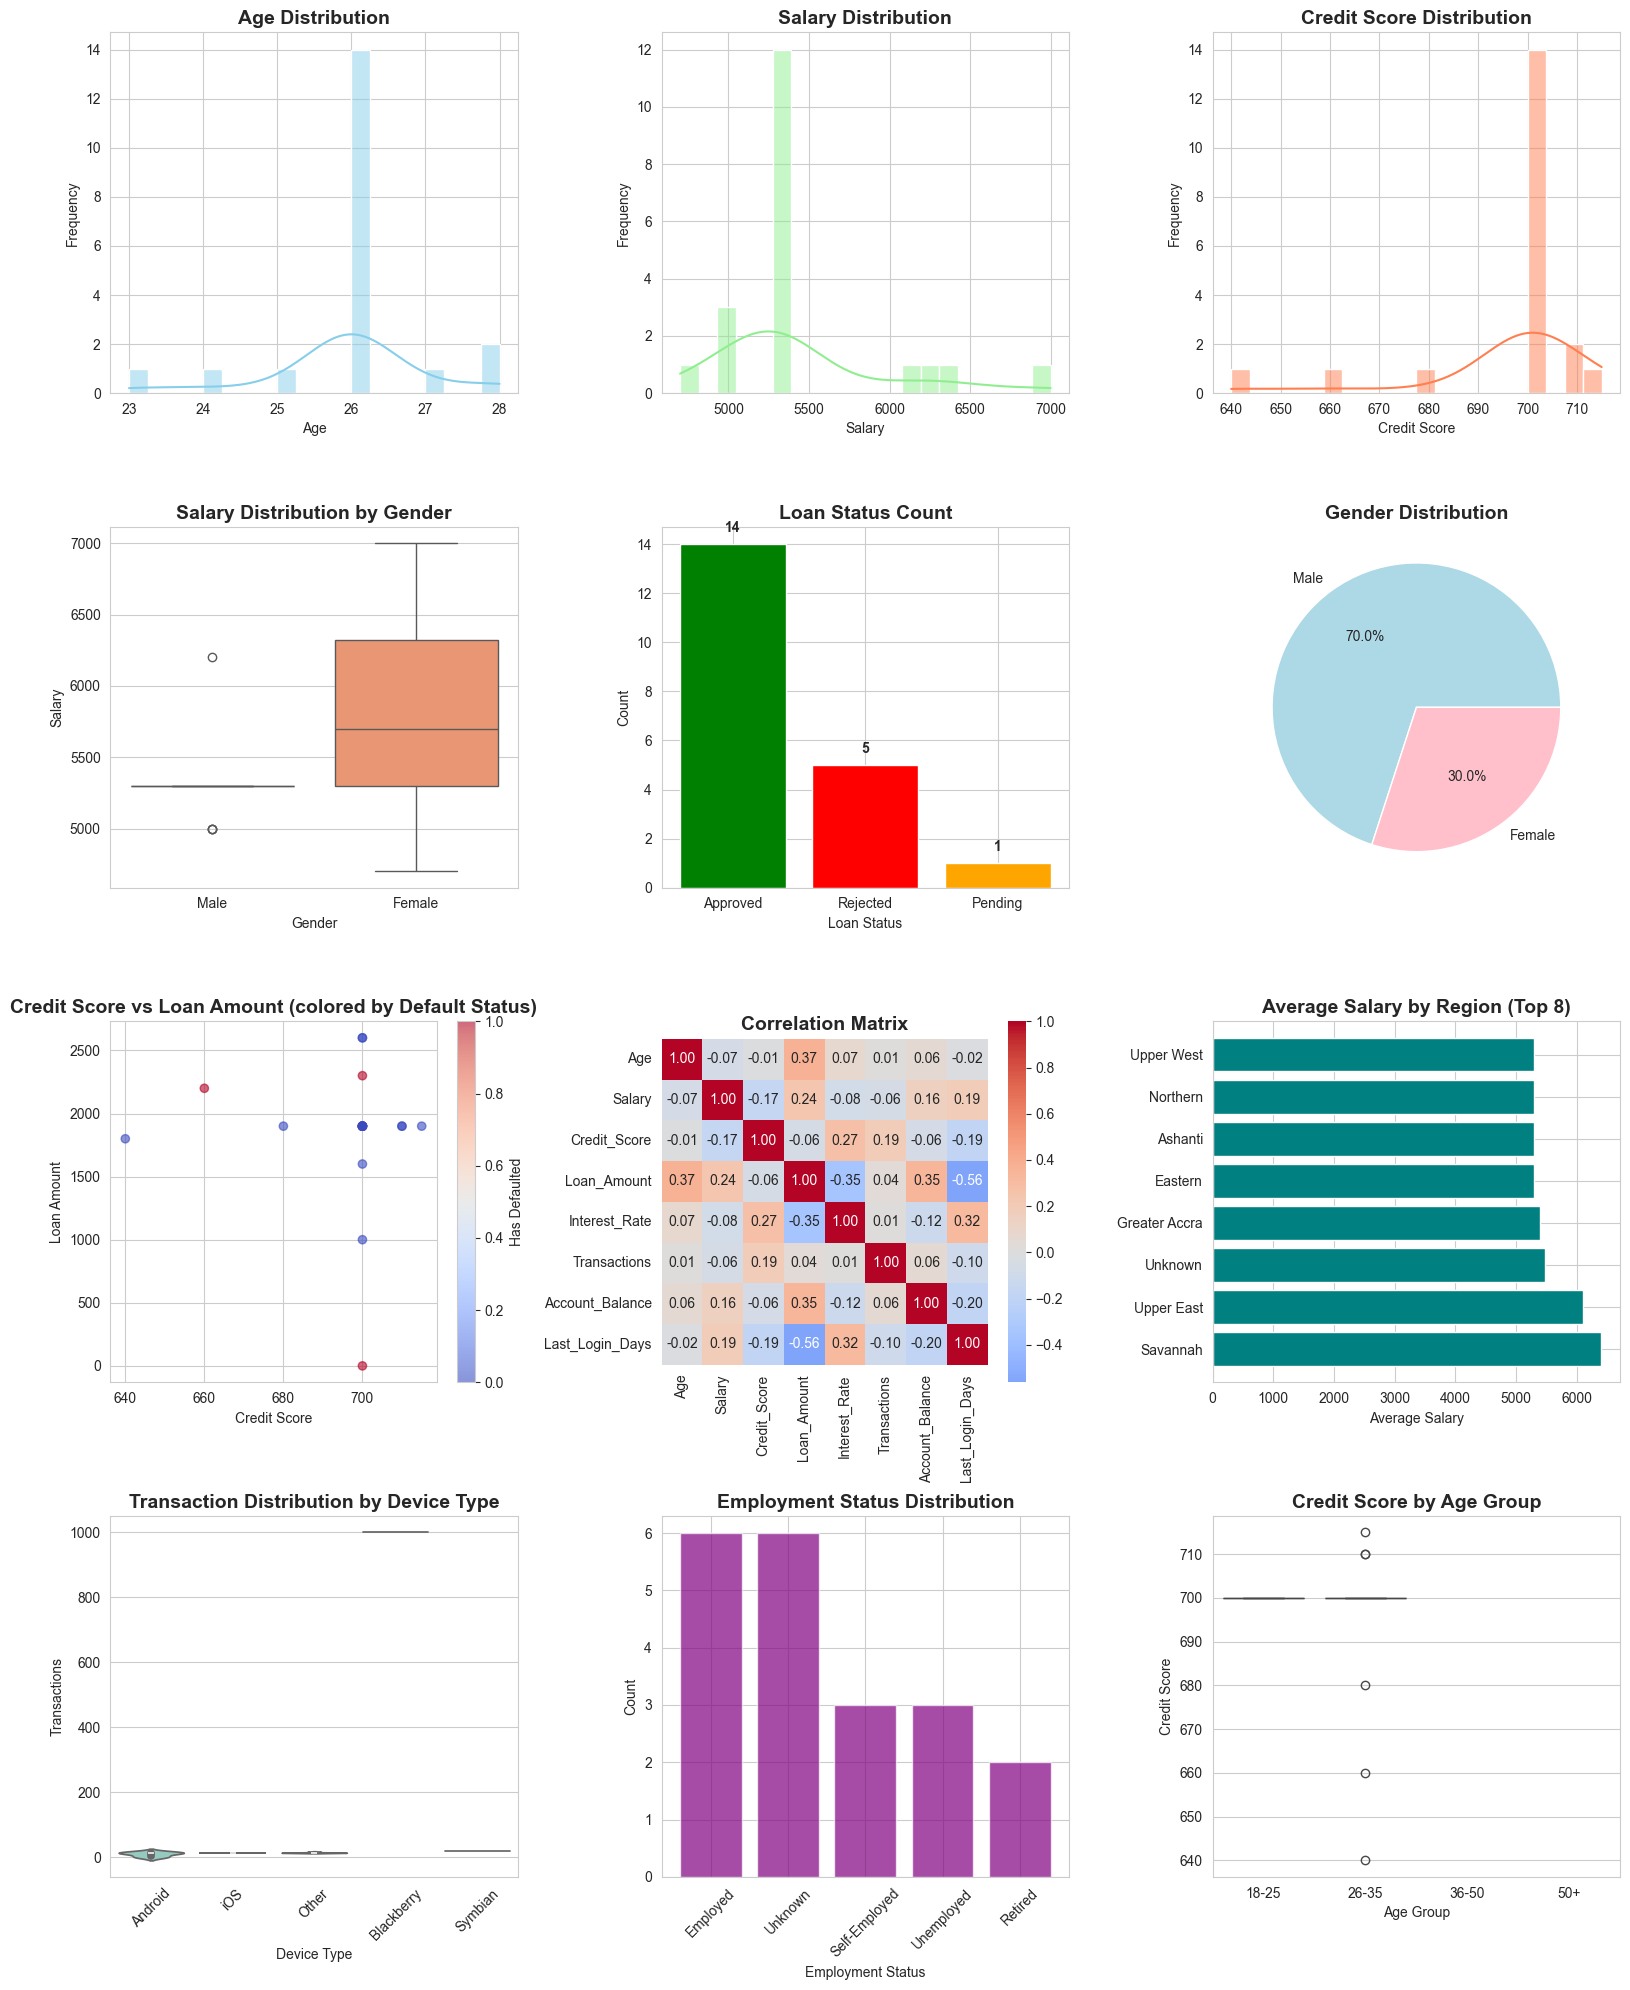


ADDITIONAL VISUALIZATIONS


<Figure size 1200x1000 with 0 Axes>

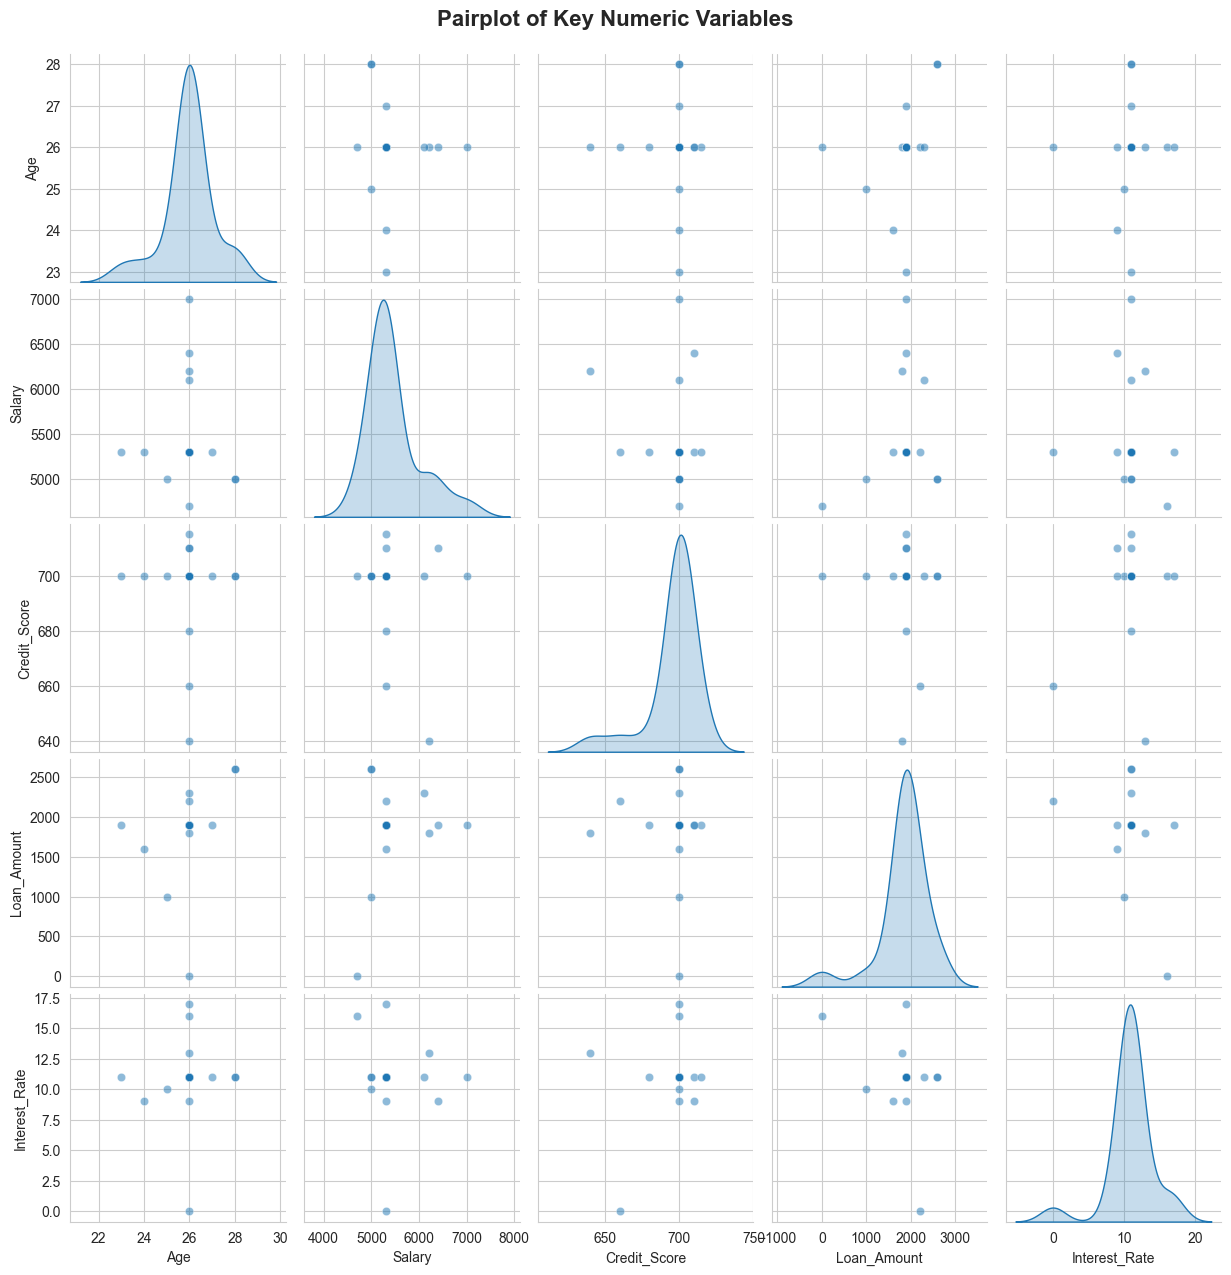

In [8]:
# ============================================
# 29. VISUALIZATIONS
# ============================================

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Create a figure with subplots
fig = plt.figure(figsize=(16, 20))

# 1. Distribution of Age
ax1 = fig.add_subplot(4, 3, 1)
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')

# 2. Distribution of Salary
ax2 = fig.add_subplot(4, 3, 2)
sns.histplot(df['Salary'], bins=20, kde=True, color='lightgreen', ax=ax2)
ax2.set_title('Salary Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Salary')
ax2.set_ylabel('Frequency')

# 3. Distribution of Credit Score
ax3 = fig.add_subplot(4, 3, 3)
sns.histplot(df['Credit_Score'], bins=20, kde=True, color='coral', ax=ax3)
ax3.set_title('Credit Score Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Credit Score')
ax3.set_ylabel('Frequency')

# 4. Box plot: Salary by Gender
ax4 = fig.add_subplot(4, 3, 4)
sns.boxplot(x='Gender', y='Salary', data=df, palette='Set2', ax=ax4)
ax4.set_title('Salary Distribution by Gender', fontsize=14, fontweight='bold')
ax4.set_xlabel('Gender')
ax4.set_ylabel('Salary')

# 5. Count plot: Loan Status
ax5 = fig.add_subplot(4, 3, 5)
loan_counts = df['Loan_Status'].value_counts()
colors = ['green', 'red', 'orange']
ax5.bar(loan_counts.index, loan_counts.values, color=colors[:len(loan_counts)])
ax5.set_title('Loan Status Count', fontsize=14, fontweight='bold')
ax5.set_xlabel('Loan Status')
ax5.set_ylabel('Count')
for i, v in enumerate(loan_counts.values):
    ax5.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 6. Count plot: Gender
ax6 = fig.add_subplot(4, 3, 6)
gender_counts = df['Gender'].value_counts()
ax6.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightblue', 'pink'])
ax6.set_title('Gender Distribution', fontsize=14, fontweight='bold')

# 7. Scatter plot: Credit Score vs Loan Amount
ax7 = fig.add_subplot(4, 3, 7)
scatter = ax7.scatter(df['Credit_Score'], df['Loan_Amount'], c=df['Has_Defaulted'], cmap='coolwarm', alpha=0.6)
ax7.set_title('Credit Score vs Loan Amount (colored by Default Status)', fontsize=14, fontweight='bold')
ax7.set_xlabel('Credit Score')
ax7.set_ylabel('Loan Amount')
plt.colorbar(scatter, ax=ax7, label='Has Defaulted')

# 8. Heatmap: Correlation matrix
ax8 = fig.add_subplot(4, 3, 8)
numeric_cols = ['Age', 'Salary', 'Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Transactions', 'Account_Balance', 'Last_Login_Days']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, ax=ax8)
ax8.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 9. Bar plot: Average Salary by Region
ax9 = fig.add_subplot(4, 3, 9)
region_salary = df.groupby('Region')['Salary'].mean().sort_values(ascending=False).head(8)
ax9.barh(range(len(region_salary)), region_salary.values, color='teal')
ax9.set_yticks(range(len(region_salary)))
ax9.set_yticklabels(region_salary.index)
ax9.set_title('Average Salary by Region (Top 8)', fontsize=14, fontweight='bold')
ax9.set_xlabel('Average Salary')

# 10. Violin plot: Transactions by Device Type
ax10 = fig.add_subplot(4, 3, 10)
top_devices = df['Device_Type'].value_counts().head(5).index
df_top_devices = df[df['Device_Type'].isin(top_devices)]
sns.violinplot(x='Device_Type', y='Transactions', data=df_top_devices, palette='Set3', ax=ax10)
ax10.set_title('Transaction Distribution by Device Type', fontsize=14, fontweight='bold')
ax10.set_xlabel('Device Type')
ax10.set_ylabel('Transactions')
plt.setp(ax10.xaxis.get_majorticklabels(), rotation=45)

# 11. Count plot: Employment Status
ax11 = fig.add_subplot(4, 3, 11)
employment_counts = df['Employment'].value_counts()
ax11.bar(employment_counts.index, employment_counts.values, color='purple', alpha=0.7)
ax11.set_title('Employment Status Distribution', fontsize=14, fontweight='bold')
ax11.set_xlabel('Employment Status')
ax11.set_ylabel('Count')
plt.setp(ax11.xaxis.get_majorticklabels(), rotation=45)

# 12. Box plot: Credit Score by Age Group
ax12 = fig.add_subplot(4, 3, 12)
sns.boxplot(x='Age_Group', y='Credit_Score', data=df, palette='Set1', ax=ax12)
ax12.set_title('Credit Score by Age Group', fontsize=14, fontweight='bold')
ax12.set_xlabel('Age Group')
ax12.set_ylabel('Credit Score')

plt.tight_layout()
plt.show()

# Additional plots
print("\n" + "="*60)
print("ADDITIONAL VISUALIZATIONS")
print("="*60)

# Pairplot for selected numeric columns
fig2 = plt.figure(figsize=(12, 10))
sns.pairplot(df[numeric_cols[:5]], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Key Numeric Variables', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [9]:
# ============================================
# 30. FINAL CLEANED DATASET SUMMARY
# ============================================

print("="*60)
print("FINAL CLEANED DATASET SUMMARY")
print("="*60)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}\n")
print(f"First 5 rows of cleaned dataset:\n{df.head()}\n")
print(f"Last 5 rows of cleaned dataset:\n{df.tail()}\n")
print(f"Missing values after cleaning:\n{df.isnull().sum().sum()}\n")
print("="*60)
print("DATA CLEANING COMPLETE!")
print("="*60)

# Save the cleaned dataframe
# df.to_csv('cleaned_data.csv', index=False)
# print("\nCleaned data saved to 'cleaned_data.csv'")

FINAL CLEANED DATASET SUMMARY
Total rows: 20
Total columns: 30

Column names:
['Customer_ID', 'Name', 'Age', 'Gender', 'City', 'Salary', 'Loan_Status', 'Year', 'Credit_Score', 'Account_Balance', 'Transactions', 'Device_Type', 'Employment', 'Marital_Status', 'Education', 'Loan_Amount', 'Interest_Rate', 'Region', 'Has_Defaulted', 'Online_User', 'Last_Login_Days', 'Age_Group', 'Salary_Category', 'Credit_Category', 'Transaction_Category', 'Debt_to_Income', 'Is_Active', 'Risk_Score', 'Tenure_Years', 'Avg_Txn_Value']

First 5 rows of cleaned dataset:
   Customer_ID     Name  Age  Gender     City  Salary Loan_Status  Year  \
0       1001.0     John   25    Male    Accra    5000    Approved  2026   
1       1002.0  Unknown   26  Female   Kumasi    7000    Rejected  2025   
2       1019.0  Unknown   26    Male  Unknown    5300    Approved  2025   
3       1004.0     Mary   26  Female  Unknown    5300    Approved  2025   
4       1005.0     Kofi   26    Male    Accra    5300    Approved  2025   